<a href="https://colab.research.google.com/github/yuliiakovall/firstrepository/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Підготовка даних


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/yulu_rental.csv')

In [8]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [14]:
print(df.shape)
df.head()

(10886, 19)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


Датасет містить 10886 рядків та 19 колонок.
Рівень деталізації погодинний

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


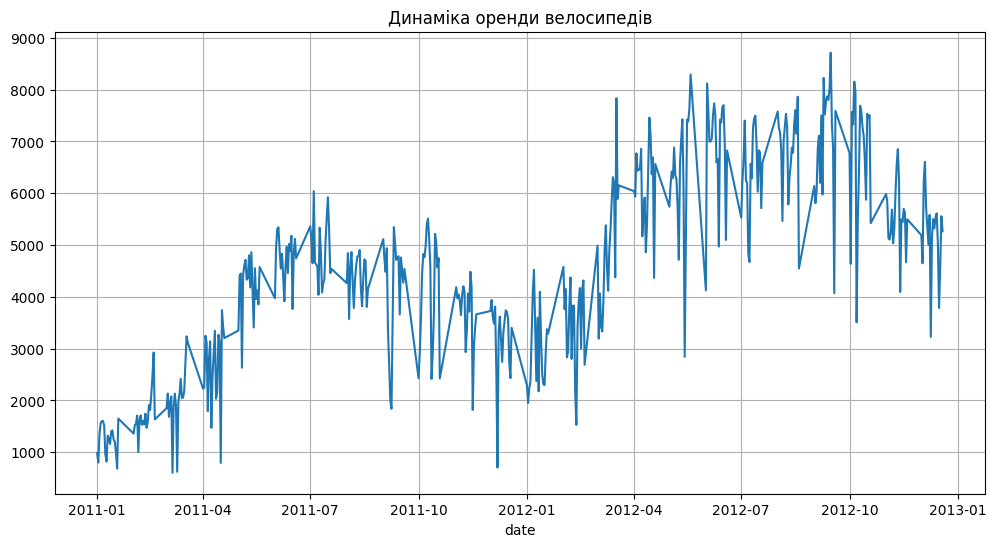

In [15]:
df.groupby('date')['count'].sum().plot(
    figsize=(12, 6),
    title="Динаміка оренди велосипедів",
    grid=True
);

“Заломи” на графіку ймовірно пов’язані з різкими денними коливаннями (погода, будні/вихідні, свята). Їх можна зменшити, якщо побудувати згладжений графік.

На графіку видно загальну тенденцію до зростання кількості оренд у теплі місяці та зниження на початку і в кінці року. У 2012 році рівень оренд загалом вищий, ніж у 2011.

Так, сезонність помітна: найбільше оренд у середині року, а найменше — взимку та на початку року.

Так, є дні з аномально низькими або високими значеннями. Ймовірні причини: погіршення погоди (дощ, вітер), свята, вихідні або інші локальні події.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

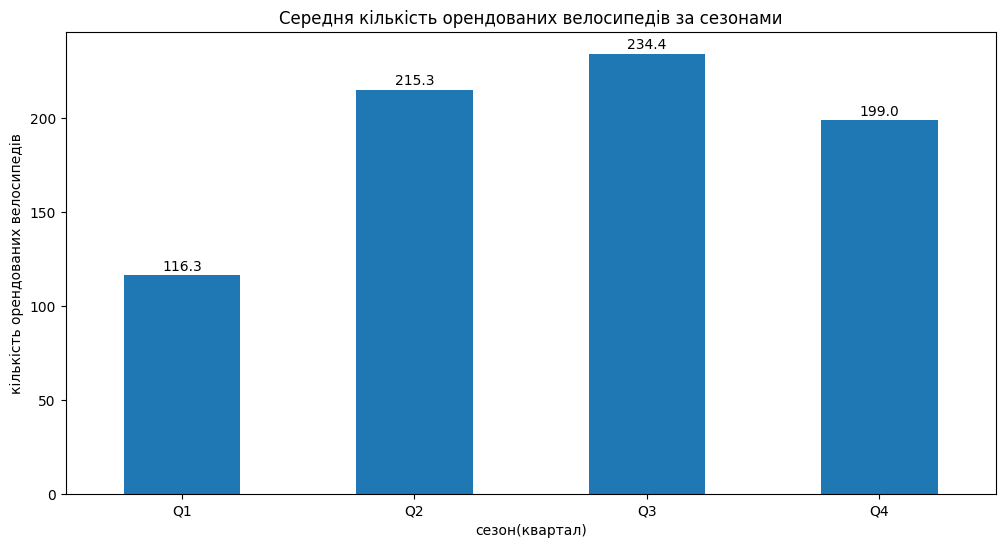

In [18]:
season_mean = df.groupby('season')['count'].mean()
season_mean.index = ['Q1', 'Q2', 'Q3', 'Q4']
ax = season_mean.plot.bar(
    figsize=(12, 6),
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel='сезон(квартал)',
    ylabel='кількість орендованих велосипедів'
)
plt.xticks(rotation=0)
for i, v in enumerate(season_mean):
    ax.text(i, v + 1, f"{v:.1f}", ha='center', va='bottom')
plt.show()

1/2 Найбільша кількість оренди припадає на 3 квартал (липень, серпень, вересень), що здається логічним, адже саме в цей сезон найкраща погода, в учбових закладах канікули і люди найчастіше беруть відпустки. 3. У 2 рази відрізняється середня кількість орендованих велосипедів у найменш популярний сезон (зима - 116) та найбільш популярний сезон (літо - 234).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


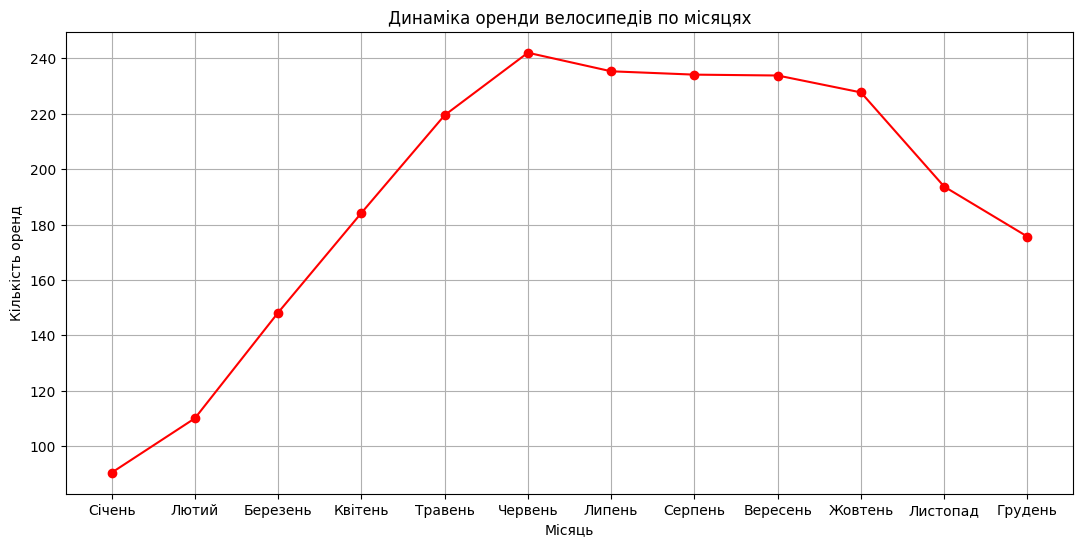

In [19]:
avg_rentals = df.groupby('month')['count'].mean()
ax = avg_rentals.plot.line(
    figsize = (13,6),
    title = 'Динаміка оренди велосипедів по місяцях',
    grid = True,
    xlabel = 'Місяць',
    ylabel = 'Кількість оренд',
    marker='o',
    color = 'red'
)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Січень', 'Лютий', 'Березень', 'Квітень', 'Травень', 'Червень', 'Липень', 'Серпень', 'Вересень', 'Жовтень', 'Листопад', 'Грудень'])
plt.show()

Пік оренди спостерігається у червні, а спад у січні.
Так, ця закономірність повністю збігається з результатами аналізу по кварталах.
Клімат є визначальним фактором для цього бізнесу (температурний режим, опади та світловий день)

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

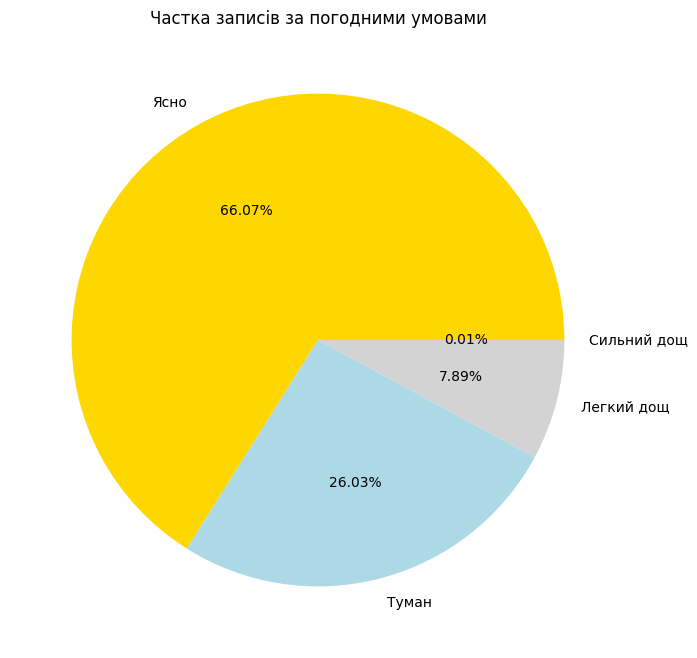

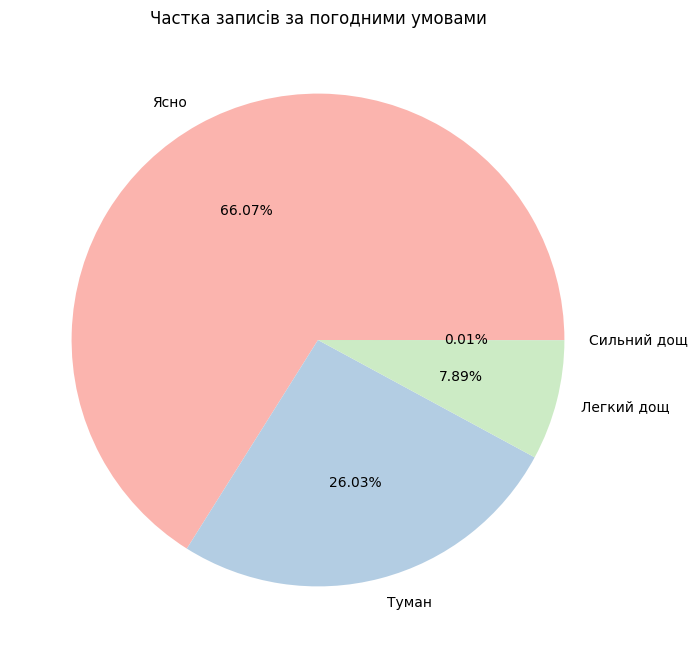

In [24]:
weather_share = df['weather'].value_counts().sort_index()
weather_share.plot.pie(
    figsize = (20,8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title = 'Частка записів за погодними умовами',
    colors=plt.cm.Pastel1.colors,
    ylabel = ''
)
plt.show()

У датасеті переважає ясна погода.
Дні із сильним дощем у датасеті є, проте їхня кількість надзвичайно мала (0,01).
Погодні умови є одним із критичних факторів впливу на оренду велосипедів

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

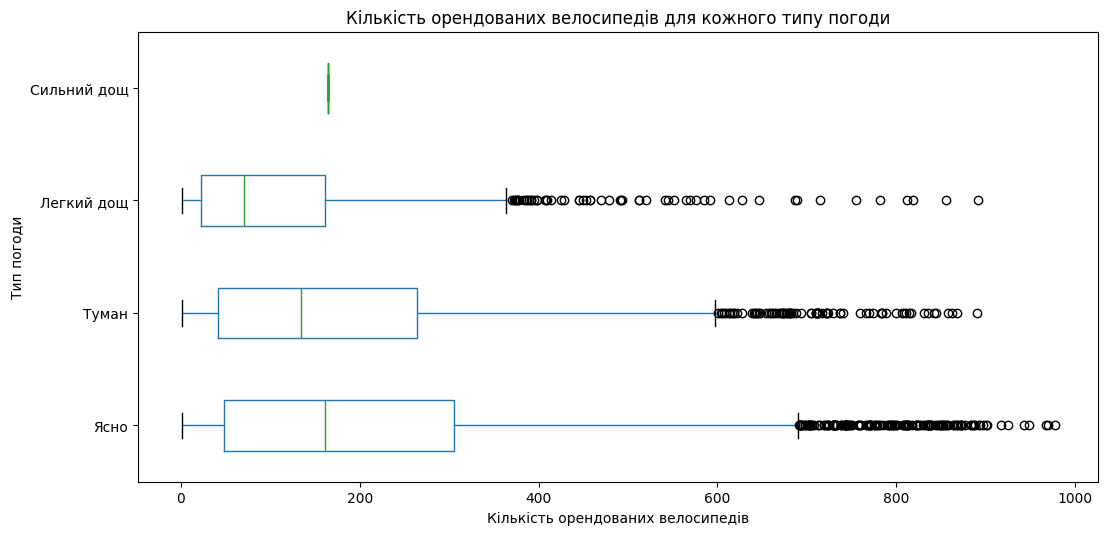

In [26]:
rentals_by_weather = df.boxplot(
    column='count',
    by='weather',
    figsize=(12, 6),
    grid = False,
    vert = False
)
plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.suptitle('')
plt.ylabel('Тип погоди')
plt.xlabel('Кількість орендованих велосипедів')
rentals_by_weather.set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

Найбільший розкид даних спостерігається при ясній погоді.

Так, у даних чітко помітні викиди. Викиди є у категоріях «Ясно», «Туман» та «Легкий дощ».

Найвище медіанне значення оренди спостерігається при ясній погоді

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

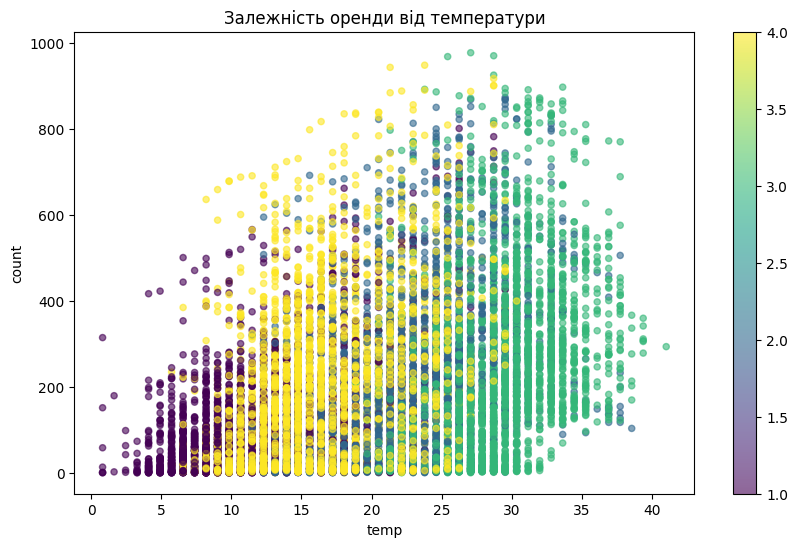

In [27]:
df.plot.scatter(
    x='temp',
    y='count',
    c=df['season'],
    colormap='viridis',
    title='Залежність оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()

Між температурою та кількістю оренди спостерігається пряма залежність. Це означає, що зі зростанням температури від
 до приблизно
 загальна кількість орендованих велосипедів схильна збільшуватися

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

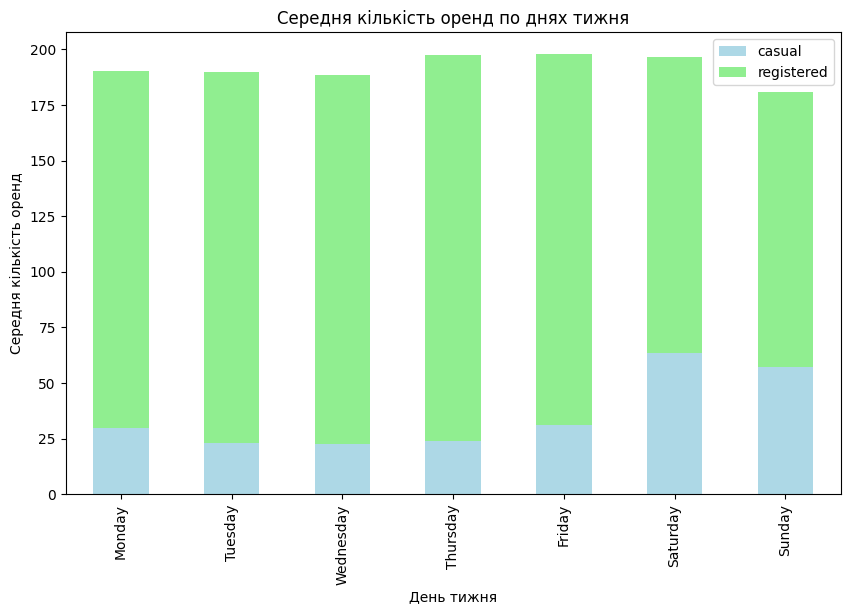

In [30]:
avg_by_weekday = df.groupby('weekday')[['casual', 'registered']].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_weekday = avg_by_weekday.reindex(weekday_order)

ax = avg_by_weekday.plot.bar(
    stacked=True,
    figsize=(10,6),
    color=['lightblue','lightgreen'],
    title='Середня кількість оренд по днях тижня'
)

plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')
plt.show()

Найвищі показники оренд від зареєстрованих користувачів спостерігаються у четвер (Thursday) та п'ятницю (Friday).

Висока активність у будні дні свідчить про те, що ця категорія використовує велосипеди як транспорт для поїздок на роботу або навчання. Блакитні сектори значно збільшуються у суботу та неділю. Це вказує на те, що незареєстровані користувачі орендують велосипеди переважно для прогулянок та відпочинку у вільний час